# Data Cleaning :Part 2

- Handling missing values and checking for duplicates is not always sufficient when cleaning a dataset. In many cases, datasets may contain inconsistent naming conventions, formatting issues, or extreme values that can negatively affect analysis results and visualizations.

In this section, we focus on improving data quality through the following steps:

1. Data Standardization
   * Ensuring that values follow consistent formats and naming conventions (e.g., consistent capitalization, country names, date formats, or category labels).
2. Handling Outliers
   * Identifying and addressing unusually large or small values that may distort statistical analysis or model performance.

## Data Standardization

Data standardization ensures that values in a dataset follow consistent formats and naming conventions. In many real-world datasets, similar values may appear in different forms e.g(`MALE`,`M`,`male`) ,which can lead to incorrect analysis results. Standardizing the data helps ensure consistency, accuracy, and better analysis

1. Converting Text to Lowercase or Upper
   ```python
        data["gender"]=data["gender"].str.lower()
        data["gender"]=data["gender"].str.upper()
     ```

2. Removing Extra Spaces
  ```python
data["country"]=data["country"].str.strip()
  ```
3. Replacing Inconsistent Names
   - Sometimes the same categories appear with different spellings
      ```python
     df["gender"]=df["gender"].replace({'male' : "MALE",
     "M":"MALE"})
     ```
4. Standardizing Date Formats
   - Dates may appear in multiple formats and should be converted to a consistent type.
      ```python
     data["date"]=pd.to_datetime(data["date"])
     ```
5. Standardize Column Names
   - Use lowercase letters and underscores instead of spaces
      ```python
     data.rename(columns={
      "Country of origin": "country_of_origin",
      "Year of Study": "year_of_study"},inplace=True)
     ```


In [2]:
import pandas as pd

In [6]:
data = {
    "student_name": [ "bob", " CHARLIE ","BONiswa", "david", "frank ","Thandi"],
    "gender": ["M", "m ", "FEMALE", "Male", "male", "female"],
    "major": ["Computer Science", "Engineering", "COMPUTER SCIENCE.",
              "Data Science", "BEng", "DATA SCIENCE"],
    "study_hours": [10, 12, 9, 8, 11, 7],
    "exam_score": [85, 90, 78, 88, 92, 75]
}

df = pd.DataFrame(data)


In [7]:
df.head(10)

,student_name,gender,major,study_hours,exam_score
0,bob,M,Computer Science,10,85
1,CHARLIE,m,Engineering,12,90
2,BONiswa,FEMALE,COMPUTER SCIENCE.,9,78
3,david,Male,Data Science,8,88
4,frank,male,BEng,11,92
5,Thandi,female,DATA SCIENCE,7,75


In [8]:
df["student_name"] = df["student_name"].str.strip()
df["gender"] = df["gender"].str.strip()
df["major"] = df["major"].str.strip()

In [9]:
df["student_name"] = df["student_name"].str.title()
df["gender"] = df["gender"].str.lower()
df["major"] = df["major"].str.lower()

In [12]:
df["major"] = df["major"].replace({
    "computer science": "Computer Science",
     "computer science.": "Computer Science",
    "data science": "Data Science",
    "beng":"Engineering",
    "engineering": "Engineering"
})

df["gender"] = df["gender"].replace({
    "female": "Female",
    "male": "Male",
    "m": "Male",

})

In [13]:
df.head(10)

,student_name,gender,major,study_hours,exam_score
0,Bob,Male,Computer Science,10,85
1,Charlie,Male,Engineering,12,90
2,Boniswa,Female,Computer Science,9,78
3,David,Male,Data Science,8,88
4,Frank,Male,Engineering,11,92
5,Thandi,Female,Data Science,7,75


## Handling Outliers

Outliers are extreme values that differ significantly from other observations in a dataset. These values may occur due to data entry errors, measurement issues, or natural variability. If not handled properly, outliers can distort statistical analysis and negatively affect machine learning models.

In Python using pandas, outliers are commonly detected using methods such as visualization, the Interquartile Range (IQR), or Z-scores.

### Step 1: Understand the Data Context
Before flagging a value as “odd,” ask:
- What is the expected range for this variable?
- Does the data type match the variable meaning (e.g., age as an integer, not a string)?
- Are there physical or logical limits (e.g., negative salaries, unrealistic temperatures)?

 `Example: A recorded “age” of 250 or “salary” of -10000 is clearly invalid`

### Step 2: Check Kurtosis — Are There Extreme Distributions?
- Kurtosis measures how heavy or light the tails of a distribution are compared to a normal distribution.
- It helps you detect columns that might contain extreme outliers.
   ```python
  df.kurtosis(numeric_only=True)
  ```
   - If kurtosis > 3: investigate those columns further — they likely have extreme values or errors.
   - If kurtosis < 0: the data might be unnaturally uniform or incorrectly rounded.

### Step 3: Investigate Outliers in High-Kurtosis Columns
Once you identify which columns have high kurtosis, use the Interquartile Range (IQR) or Z-score method to find specific outliers

Sometimes, after removing your first batch of outliers, you might find new outliers appearing when you re-run your detection process.
These are called nested outliers.
#### What Are Nested Outliers?
Nested outliers are values that only appear extreme after the most obvious outliers have been removed.

<img src="img_1.png" width="400">

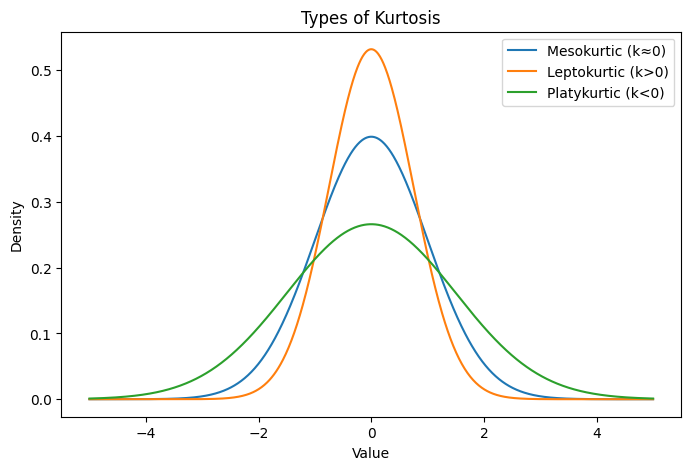

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, kurtosis

# Create x-axis
x = np.linspace(-5, 5, 1000)

# Mesokurtic (normal)
y_mesokurtic = norm.pdf(x, 0, 1)

# Leptokurtic (tighter peak, heavier tails)
y_leptokurtic = norm.pdf(x, 0, 0.75)

# Platykurtic (flatter peak, lighter tails)
y_platykurtic = norm.pdf(x, 0, 1.5)

plt.figure(figsize=(8,5))
plt.plot(x, y_mesokurtic, label='Mesokurtic (k≈0)')
plt.plot(x, y_leptokurtic, label='Leptokurtic (k>0)')
plt.plot(x, y_platykurtic, label='Platykurtic (k<0)')
plt.title("Types of Kurtosis")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

In [16]:
data = {
    "student_name": ["Boniswa", "Bob", "Charlie", "David", "Eva", "Frank", "Thandi"],
    "study_hours": [10, 12, 9, 8, 11, 7, 40],
    "exam_score": [85, 90, 78, 88, 92, 2, 20]
}

In [17]:
df = pd.DataFrame(data)

df.head(10)

,student_name,study_hours,exam_score
0,Boniswa,10,85
1,Bob,12,90
2,Charlie,9,78
3,David,8,88
4,Eva,11,92
5,Frank,7,2
6,Thandi,40,20


### Detecting Outliers Using IQR

The Interquartile Range (IQR) method identifies outliers based on the spread of the middle 50% of the data.

In [24]:
Q1 = df["study_hours"].quantile(0.25)
Q3 = df["study_hours"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["study_hours"] < lower_bound) | (df["study_hours"] > upper_bound)]

print(outliers)


  student_name  study_hours  exam_score
6       Thandi           40          20


### Removing Outliers

In [25]:
df_clean = df[(df["study_hours"] >= lower_bound) & (df["study_hours"] <= upper_bound)]

print(df_clean)

  student_name  study_hours  exam_score
0      Boniswa           10          85
1          Bob           12          90
2      Charlie            9          78
3        David            8          88
4          Eva           11          92
5        Frank            7           2


### Handling Outliers by Capping (Winsorization)
Instead of removing data, sometimes it is better to cap extreme values.

#### Why Use clip() Instead of Removing Data?

clip() is useful when:
* You don't want to lose observations
* Extreme values may still contain useful information
* You want to reduce the impact of outliers

In [26]:
df["study_hours"] = df["study_hours"].clip(lower_bound, upper_bound)

In [27]:
df.head(10)

,student_name,study_hours,exam_score
0,Boniswa,10,85
1,Bob,12,90
2,Charlie,9,78
3,David,8,88
4,Eva,11,92
5,Frank,7,2
6,Thandi,16,20


- Now that you have clean data,its time to do some analysis and get some insights relating to your problem statement